<a href="https://colab.research.google.com/github/gunavathibaskaran170/AI-project-/blob/main/AGGLOMERATIVE_CLUSTERING_FOR_CUSTOMER_SEGMENTATION_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("Mall_Customers (1).csv")

In [ ]:
df.head()

,CustomerID,Genre,Age,Annual_Income_(k$),Spending_Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df.tail()

,CustomerID,Genre,Age,Annual_Income_(k$),Spending_Score
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


In [ ]:
df.describe()

,CustomerID,Age,Annual_Income_(k$),Spending_Score
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   CustomerID          200 non-null    int64 
 1   Genre               200 non-null    object
 2   Age                 200 non-null    int64 
 3   Annual_Income_(k$)  200 non-null    int64 
 4   Spending_Score      200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
df.shape

(200, 5)

In [ ]:
df.size

1000

In [ ]:
df.isnull().sum()

CustomerID            0
Genre                 0
Age                   0
Annual_Income_(k$)    0
Spending_Score        0
dtype: int64

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage,fcluster

In [ ]:
X=df[["Annual_Income_(k$)"]]
y=df["Spending_Score"]

In [ ]:
X=StandardScaler().fit_transform(X)

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
z=linkage(X,method='ward')

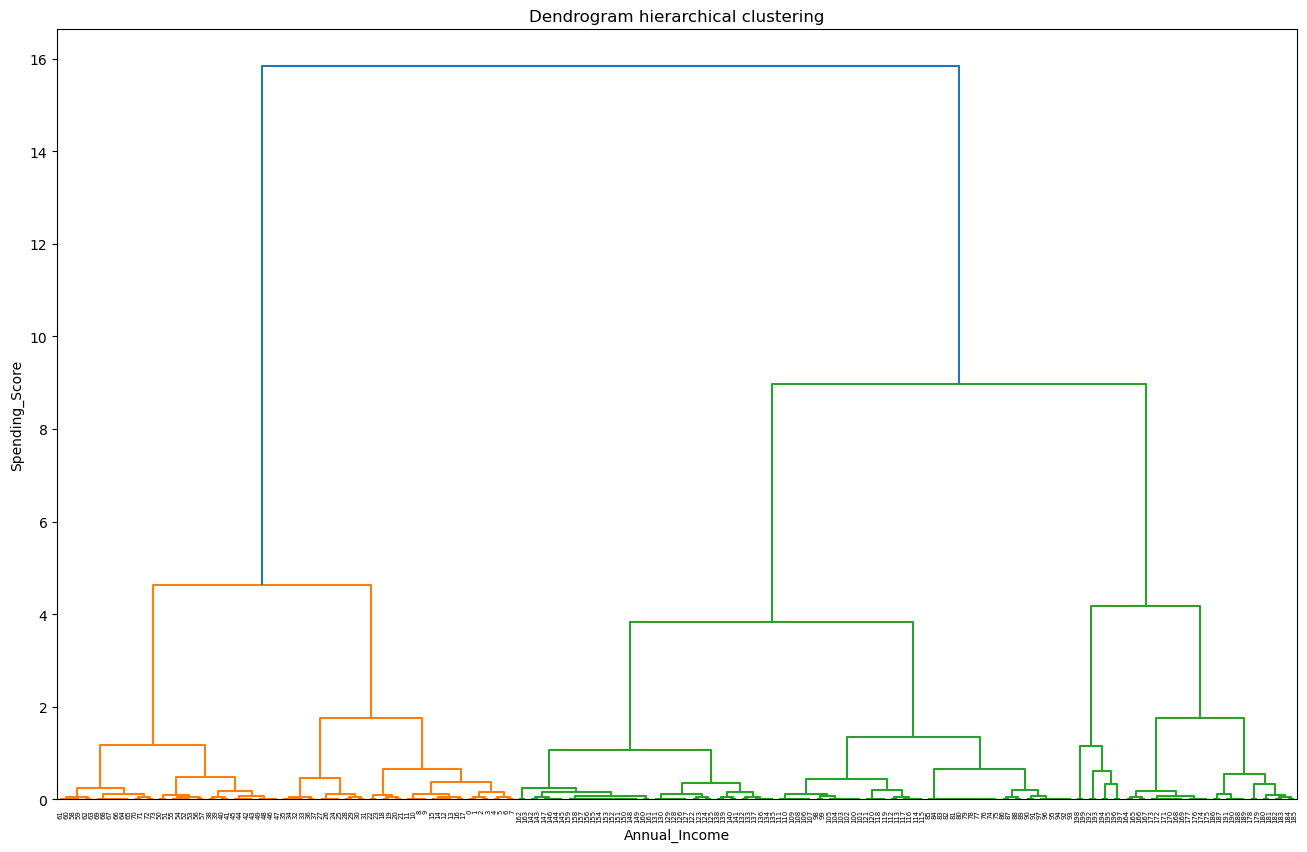

In [ ]:
plt.figure(figsize=(16,10))
dendrogram(z)
plt.title("Dendrogram hierarchical clustering")
plt.xlabel("Annual_Income")
plt.ylabel("Spending_Score")
plt.show()

In [ ]:
labels=fcluster(z,t=4,criterion='maxclust')

In [ ]:
plt.figure(figsize=(16,10))

<Figure size 1600x1000 with 0 Axes>

<Figure size 1600x1000 with 0 Axes>

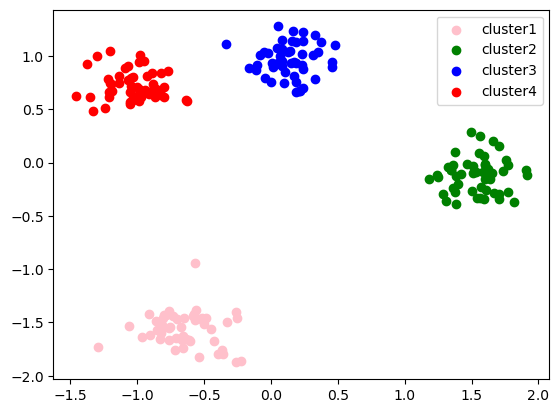

In [ ]:
plt.scatter(X[labels == 1, 0], X[labels == 1, 1], color="pink", label="cluster1")
plt.scatter(X[labels == 2, 0], X[labels == 2, 1], color="green", label="cluster2")
plt.scatter(X[labels == 3, 0], X[labels == 3, 1], color="blue", label="cluster3")
plt.scatter(X[labels == 4, 0], X[labels == 4, 1], color="red", label="cluster4")

plt.legend()
plt.show()

In [ ]:
ac=AgglomerativeClustering(n_clusters=4,linkage='ward')

In [ ]:
q = df[["Annual_Income_(k$)", "Spending_Score"]].values
y_ac=ac.fit_predict(q)

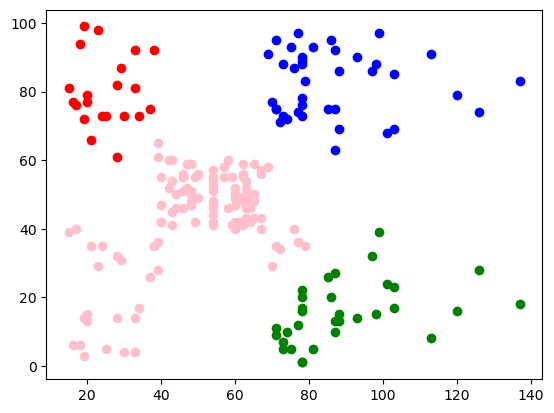

In [ ]:
plt.scatter(q[y_ac==0,0], q[y_ac==0,1], color="pink", label="cluster1")
plt.scatter(q[y_ac==1,0], q[y_ac==1,1], color="green", label="cluster2")
plt.scatter(q[y_ac==2,0], q[y_ac==2,1], color="blue", label="cluster3")
plt.scatter(q[y_ac==3,0], q[y_ac==3,1], color="red", label="cluster4")
plt.scatter(q[y_ac==4,0], q[y_ac==4,1], color="yellow", label="cluster5")
plt.scatter(q[y_ac==5,0], q[y_ac==5,1], color="orange", label="cluster6")
plt.scatter(q[y_ac==-1,0], q[y_ac==-1,1], color="black", marker="x")